In [11]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

pd.set_option("display.max_columns", None)

In [12]:
fraud = pd.read_csv(
    "../data/processed/fraud_processed.csv"
)

fraud.head()

,user_id,purchase_value,device_id,age,ip_address,class,lower_bound_ip_address,upper_bound_ip_address,time_since_signup,hour_of_day,day_of_week,transaction_count,device_transaction_count,time_between_transactions,source_Direct,source_SEO,browser_FireFox,browser_IE,browser_Opera,browser_Safari,sex_M,country_Albania,country_Algeria,country_Angola,country_Antigua and Barbuda,country_Argentina,country_Armenia,country_Australia,country_Austria,country_Azerbaijan,country_Bahamas,country_Bahrain,country_Bangladesh,country_Barbados,country_Belarus,country_Belgium,country_Belize,country_Benin,country_Bermuda,country_Bhutan,country_Bolivia,country_Bonaire; Sint Eustatius; Saba,country_Bosnia and Herzegowina,country_Botswana,country_Brazil,country_British Indian Ocean Territory,country_Brunei Darussalam,country_Bulgaria,country_Burkina Faso,country_Burundi,country_Cambodia,country_Cameroon,country_Canada,country_Cape Verde,country_Cayman Islands,country_Chile,country_China,country_Colombia,country_Congo,country_Congo The Democratic Republic of The,country_Costa Rica,country_Cote D'ivoire,country_Croatia (LOCAL Name: Hrvatska),country_Cuba,country_Curacao,country_Cyprus,country_Czech Republic,country_Denmark,country_Djibouti,country_Dominica,country_Dominican Republic,country_Ecuador,country_Egypt,country_El Salvador,country_Estonia,country_Ethiopia,country_European Union,country_Faroe Islands,country_Fiji,country_Finland,country_France,country_Gabon,country_Gambia,country_Georgia,country_Germany,country_Ghana,country_Gibraltar,country_Greece,country_Guadeloupe,country_Guam,country_Guatemala,country_Haiti,country_Honduras,country_Hong Kong,country_Hungary,country_Iceland,country_India,country_Indonesia,country_Iran (ISLAMIC Republic Of),country_Iraq,country_Ireland,country_Israel,country_Italy,country_Jamaica,country_Japan,country_Jordan,country_Kazakhstan,country_Kenya,country_Korea Republic of,country_Kuwait,country_Kyrgyzstan,country_Lao People's Democratic Republic,country_Latvia,country_Lebanon,country_Lesotho,country_Libyan Arab Jamahiriya,country_Liechtenstein,country_Lithuania,country_Luxembourg,country_Macau,country_Macedonia,country_Madagascar,country_Malawi,country_Malaysia,country_Maldives,country_Malta,country_Mauritius,country_Mexico,country_Moldova Republic of,country_Monaco,country_Mongolia,country_Montenegro,country_Morocco,country_Mozambique,country_Myanmar,country_Namibia,country_Nauru,country_Nepal,country_Netherlands,country_New Caledonia,country_New Zealand,country_Nicaragua,country_Niger,country_Nigeria,country_Norway,country_Oman,country_Pakistan,country_Palestinian Territory Occupied,country_Panama,country_Papua New Guinea,country_Paraguay,country_Peru,country_Philippines,country_Poland,country_Portugal,country_Puerto Rico,country_Qatar,country_Reunion,country_Romania,country_Russian Federation,country_Rwanda,country_Saint Kitts and Nevis,country_Saint Martin,country_San Marino,country_Saudi Arabia,country_Senegal,country_Serbia,country_Seychelles,country_Singapore,country_Slovakia (SLOVAK Republic),country_Slovenia,country_South Africa,country_South Sudan,country_Spain,country_Sri Lanka,country_Sudan,country_Sweden,country_Switzerland,country_Syrian Arab Republic,country_Taiwan; Republic of China (ROC),country_Tajikistan,country_Tanzania United Republic of,country_Thailand,country_Trinidad and Tobago,country_Tunisia,country_Turkey,country_Turkmenistan,country_Uganda,country_Ukraine,country_United Arab Emirates,country_United Kingdom,country_United States,country_Uruguay,country_Uzbekistan,country_Vanuatu,country_Venezuela,country_Viet Nam,country_Virgin Islands (U.S.),country_Yemen,country_Zambia,country_Zimbabwe
0,2,0.931750,FGBQNDNBETFJJ,-0.943490,880217484,0,8.724152e+08,8.891924e+08,-0.435282,10,5,0.0,-0.259874,0.0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,F

In [13]:
fraud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129146 entries, 0 to 129145
Columns: 201 entries, user_id to country_Zimbabwe
dtypes: bool(187), float64(8), int64(5), object(1)
memory usage: 36.8+ MB


In [14]:
X = fraud.drop(
    columns=[
        "class",
        "user_id",
        "device_id"
    ],
    errors="ignore"
)

y = fraud["class"]

In [15]:
bool_cols = X.select_dtypes(
    include=["bool"]
).columns

X[bool_cols] = X[bool_cols].astype(int)

In [16]:
non_numeric = X.select_dtypes(
    exclude=["int64", "float64"]
)

print(non_numeric.dtypes)

Series([], dtype: object)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [18]:
print("Before SMOTE")

print(y_train.value_counts())

print(
    y_train.value_counts(normalize=True) * 100
)

Before SMOTE
class
0    93502
1     9814
Name: count, dtype: int64
class
0    90.500987
1     9.499013
Name: proportion, dtype: float64


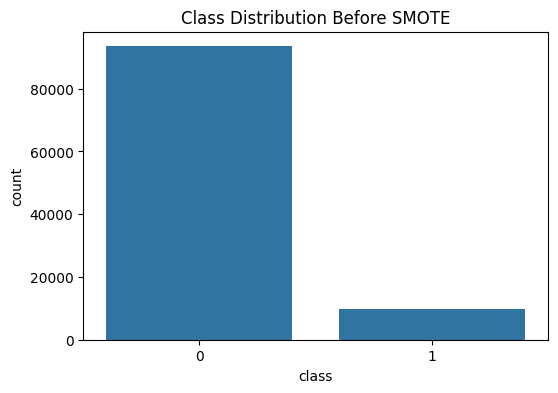

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_train)

plt.title("Class Distribution Before SMOTE")

plt.show()

In [20]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = (
    smote.fit_resample(
        X_train,
        y_train
    )
)

In [21]:
print("After SMOTE")

print(y_train_smote.value_counts())

print(
    y_train_smote.value_counts(normalize=True) * 100
)

After SMOTE
class
0    93502
1    93502
Name: count, dtype: int64
class
0    50.0
1    50.0
Name: proportion, dtype: float64


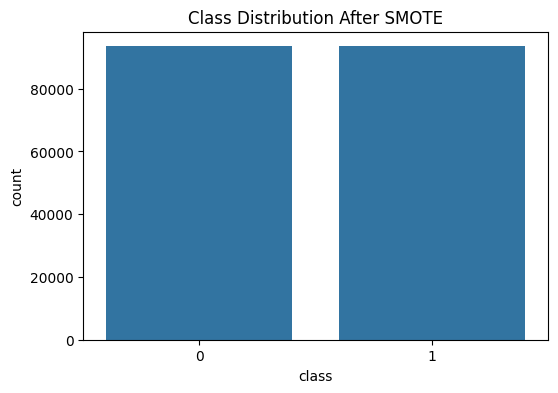

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_train_smote)

plt.title("Class Distribution After SMOTE")

plt.show()

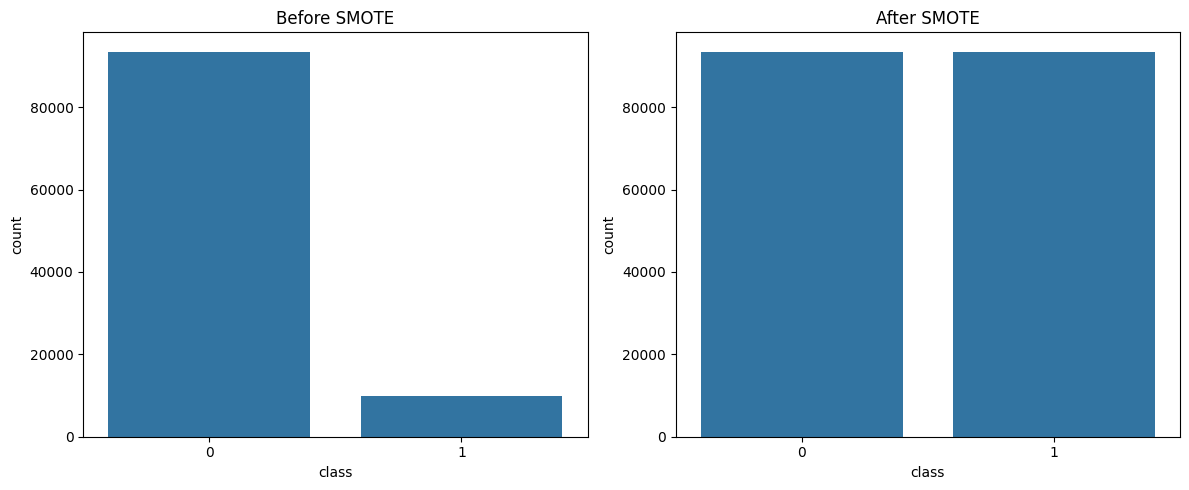

In [23]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

sns.countplot(
    x=y_train,
    ax=ax[0]
)

ax[0].set_title(
    "Before SMOTE"
)

sns.countplot(
    x=y_train_smote,
    ax=ax[1]
)

ax[1].set_title(
    "After SMOTE"
)

plt.tight_layout()

plt.show()

In [24]:
train_smote = X_train_smote.copy()

train_smote["class"] = y_train_smote

train_smote.to_csv(
    "../data/processed/fraud_train_smote.csv",
    index=False
)

In [25]:
test_df = X_test.copy()

test_df["class"] = y_test

test_df.to_csv(
    "../data/processed/fraud_test.csv",
    index=False
)

In [26]:
print("Training Shape:", X_train_smote.shape)
print("Test Shape:", X_test.shape)

print("\nTraining Distribution")

print(y_train_smote.value_counts())

print("\nTest Distribution")

print(y_test.value_counts())

Training Shape: (187004, 198)
Test Shape: (25830, 198)

Training Distribution
class
0    93502
1    93502
Name: count, dtype: int64

Test Distribution
class
0    23376
1     2454
Name: count, dtype: int64
